# CS3807 – Deep Learning Laboratory
## Experiment 6: End-to-End Study of RNN, LSTM and GRU for Sequence Learning and Video Understanding

This notebook implements the complete experiment: HAR sequence classification with SimpleRNN/LSTM/GRU,
BPTT numerical exercise, sequence-length study, CNN+RNN video understanding, and a synthetic
sequence-to-sequence (encoder–decoder) task.

**Note on dataset paths:** Update `HAR_ROOT` and `VIDEO_ROOT` in the configuration cell below to match
your local folder locations before running.

## 0. Imports and Global Configuration

In [3]:
import os
import re
import time
import math
import random
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU available: True


In [54]:
# ------------------------------------------------------------------------
# CONFIGURATION -- update these paths to match your environment
# ------------------------------------------------------------------------

# Root of the UCI HAR dataset. This folder must contain 'train/' and 'test/'
# subfolders, each with an 'Inertial Signals' folder and a y_<split>.txt file.
HAR_ROOT = "/kaggle/input/datasets/uvaiszufar/uci-har"

# Root of the UCF101 (subset) video dataset downloaded from Kaggle.
# Expected structure: VIDEO_ROOT/<ClassName>/<video files: .avi/.mp4>
VIDEO_ROOT = "/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/train"

# Subset size for the HAR experiment (recommended 1500-3000 windows, balanced across classes)
HAR_SUBSET_SIZE = 3000

# Video classes to use (must match folder names under VIDEO_ROOT)
VIDEO_CLASSES = ["Basketball", "Biking", "WalkingWithDog", "Running", "TennisSwing"]
NUM_FRAMES_PER_VIDEO = 10
FRAME_SIZE = (224, 224)

ACTIVITY_MAP = {
    1: "WALKING",
    2: "WALKING_UPSTAIRS",
    3: "WALKING_DOWNSTAIRS",
    4: "SITTING",
    5: "STANDING",
    6: "LAYING",
}
CLASS_NAMES = [ACTIVITY_MAP[i] for i in range(1, 7)]
print("Activity classes:", CLASS_NAMES)

Activity classes: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


## 3. Dataset Loading — Raw Inertial Signals

We load the nine raw signal channels (body acceleration x/y/z, body gyroscope x/y/z, total
acceleration x/y/z) from the `Inertial Signals` folders, for both the official `train` and
`test` partitions, and combine them into one pool. We then draw our own balanced 70/15/15
train/validation/test split from this pool (as required by the lab), rather than using the
official UCI train/test boundary directly, since the experiment specifically asks for a
70/15/15 protocol that must not be touched during model selection.

In [5]:
SIGNAL_NAMES = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

def load_raw_signals(root, split):
    """Load the 9-channel raw inertial signals and labels for a given split
    ('train' or 'test') of the UCI HAR dataset."""
    signal_dir = os.path.join(root, split, "Inertial Signals")
    channels = []
    for name in SIGNAL_NAMES:
        fpath = os.path.join(signal_dir, f"{name}_{split}.txt")
        channels.append(np.loadtxt(fpath))
    X = np.stack(channels, axis=-1)  # (N, 128, 9)
    y = np.loadtxt(os.path.join(root, split, f"y_{split}.txt")).astype(int)
    return X, y

X_train_raw, y_train_raw = load_raw_signals(HAR_ROOT, "train")
X_test_raw, y_test_raw = load_raw_signals(HAR_ROOT, "test")

X_all = np.concatenate([X_train_raw, X_test_raw], axis=0)
y_all = np.concatenate([y_train_raw, y_test_raw], axis=0)

print("Combined raw pool shape:", X_all.shape, "| Labels:", y_all.shape)
print("Class distribution in full pool:")
for c in range(1, 7):
    print(f"  {ACTIVITY_MAP[c]:20s}: {np.sum(y_all == c)}")

Combined raw pool shape: (10299, 128, 9) | Labels: (10299,)
Class distribution in full pool:
  WALKING             : 1722
  WALKING_UPSTAIRS    : 1544
  WALKING_DOWNSTAIRS  : 1406
  SITTING             : 1777
  STANDING            : 1906
  LAYING              : 1944


In [6]:
# ------------------------------------------------------------------------
# Balanced subset (1500-3000 windows) -- stratified sample from the full pool
# ------------------------------------------------------------------------
per_class = HAR_SUBSET_SIZE // 6

subset_idx = []
rng = np.random.RandomState(SEED)
for c in range(1, 7):
    class_idx = np.where(y_all == c)[0]
    chosen = rng.choice(class_idx, size=min(per_class, len(class_idx)), replace=False)
    subset_idx.append(chosen)
subset_idx = np.concatenate(subset_idx)
rng.shuffle(subset_idx)

X_sub = X_all[subset_idx]
y_sub = y_all[subset_idx]

print("Balanced subset shape:", X_sub.shape)
print("Class distribution in subset:")
for c in range(1, 7):
    print(f"  {ACTIVITY_MAP[c]:20s}: {np.sum(y_sub == c)}")

Balanced subset shape: (3000, 128, 9)
Class distribution in subset:
  WALKING             : 500
  WALKING_UPSTAIRS    : 500
  WALKING_DOWNSTAIRS  : 500
  SITTING             : 500
  STANDING            : 500
  LAYING              : 500


## 5. Preprocessing

Steps: encode labels to 0-indexed integers, split into 70% train / 15% validation / 15% test
(stratified, so class balance is preserved in every split), normalize using statistics computed
from the training split only, and verify the class distribution.

In [7]:
# Encode labels to 0..5 (sparse_categorical_crossentropy expects 0-indexed labels)
y_enc = y_sub - 1

# 70% train, 30% temp -> split temp into 15%/15%
X_train, X_temp, y_train, y_temp = train_test_split(
    X_sub, y_enc, test_size=0.30, stratify=y_enc, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print("Input tensor shape:")
print(f"  Training   : {X_train.shape}")
print(f"  Validation : {X_val.shape}")
print(f"  Testing    : {X_test.shape}")
print(f"Number of classes: {len(CLASS_NAMES)}")
print(f"Number of features per time step: {X_train.shape[2]}")
print(f"Sequence length: {X_train.shape[1]}")

Input tensor shape:
  Training   : (2100, 128, 9)
  Validation : (450, 128, 9)
  Testing    : (450, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128


In [8]:
# Normalize using training-set statistics only (per-channel mean/std)
train_mean = X_train.mean(axis=(0, 1), keepdims=True)
train_std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_n = (X_train - train_mean) / train_std
X_val_n = (X_val - train_mean) / train_std
X_test_n = (X_test - train_mean) / train_std

print("Normalization complete. Train mean (per channel):", train_mean.ravel())
print("Train std (per channel):", train_std.ravel())

Normalization complete. Train mean (per channel): [-4.94196211e-04 -4.45570279e-04 -9.37270884e-05 -4.11652641e-03
 -2.28063257e-05 -3.77000630e-04  8.27878287e-01  3.78569154e-04
  7.22071966e-02]
Train std (per channel): [0.20500849 0.12943156 0.10881181 0.43167301 0.38934399 0.26640858
 0.40554559 0.38835029 0.33257772]


In [9]:
# Verify class distribution across splits
def class_distribution(y, name):
    counts = np.bincount(y, minlength=6)
    print(f"{name}:")
    for i, c in enumerate(counts):
        print(f"  {CLASS_NAMES[i]:20s}: {c}")

class_distribution(y_train, "Training set")
class_distribution(y_val, "Validation set")
class_distribution(y_test, "Test set")

Training set:
  WALKING             : 350
  WALKING_UPSTAIRS    : 350
  WALKING_DOWNSTAIRS  : 350
  SITTING             : 350
  STANDING            : 350
  LAYING              : 350
Validation set:
  WALKING             : 75
  WALKING_UPSTAIRS    : 75
  WALKING_DOWNSTAIRS  : 75
  SITTING             : 75
  STANDING            : 75
  LAYING              : 75
Test set:
  WALKING             : 75
  WALKING_UPSTAIRS    : 75
  WALKING_DOWNSTAIRS  : 75
  SITTING             : 75
  STANDING            : 75
  LAYING              : 75


## 6. Temporal Data Visualization

**Plot 1: Sensor signal vs. time**, for at least three channels, across at least three
different activity classes.

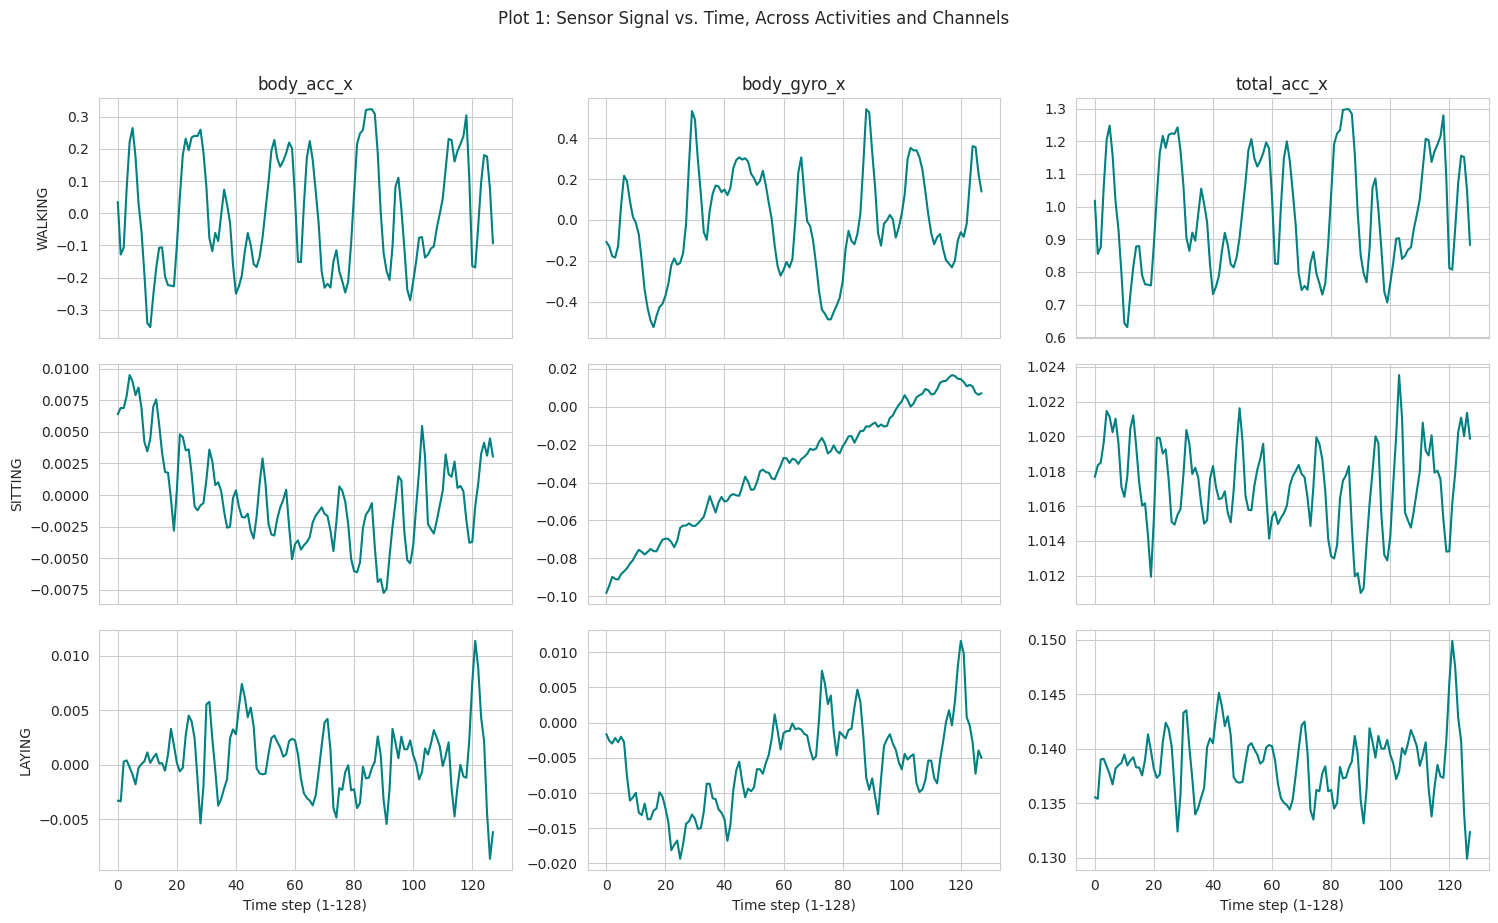

In [10]:
plot_classes = ["WALKING", "SITTING", "LAYING"]
plot_channels = ["body_acc_x", "body_gyro_x", "total_acc_x"]
channel_idx = {name: i for i, name in enumerate(SIGNAL_NAMES)}

fig, axes = plt.subplots(len(plot_classes), len(plot_channels), figsize=(15, 9), sharex=True)

for row, cname in enumerate(plot_classes):
    class_label = [k for k, v in ACTIVITY_MAP.items() if v == cname][0] - 1
    sample_idx = np.where(y_train == class_label)[0][0]
    sample = X_train[sample_idx]  # unnormalized, original units, shape (128,9)
    for col, chname in enumerate(plot_channels):
        ax = axes[row, col]
        ax.plot(range(128), sample[:, channel_idx[chname]], color="teal")
        if row == 0:
            ax.set_title(chname)
        if col == 0:
            ax.set_ylabel(cname)
        if row == len(plot_classes) - 1:
            ax.set_xlabel("Time step (1-128)")

fig.suptitle("Plot 1: Sensor Signal vs. Time, Across Activities and Channels", y=1.02)
plt.tight_layout()
plt.show()

**Inference (Plot 1):**
1. *Temporal pattern:* Dynamic activities (WALKING) show clear periodic, oscillating signals
   in both accelerometer and gyroscope channels, reflecting the repetitive motion of walking.
   Static activities (SITTING, LAYING) show comparatively flat, low-variance signals since the
   body is largely stationary and the sensor mainly records gravity/orientation with small noise.
2. *Similar activities:* SITTING and LAYING often look similar to each other (both flat/static),
   while WALKING, WALKING_UPSTAIRS and WALKING_DOWNSTAIRS look similar to each other (all
   periodic), which is consistent with them being the most confused pairs in later confusion
   matrices.
3. *Why ordering matters:* Each window encodes a motion pattern that only makes sense as a
   sequence — shuffling the 128 time steps would destroy the periodicity/trend information the
   recurrent models rely on, even though the individual values would be unchanged. This is
   precisely why the input must be processed as an ordered sequence (RNN/LSTM/GRU) rather than
   as a flat, order-independent feature vector.

## 7. Vanilla RNN Architecture

A Vanilla RNN maintains a hidden state updated at every time step:

$$h_t = \tanh(W_x x_t + W_h h_{t-1} + b_h)$$

$$y_t = g(W_y h_t + b_y)$$

The same recurrent weights ($W_x$, $W_h$, $b_h$) are reused at every time step (weight sharing
across time), and for sequence classification the final hidden state $h_T$ is passed to a
classifier head.

## 8. Backpropagation Through Time (BPTT)

When the RNN is unrolled across time steps, the loss at the end of the sequence depends on the
entire chain of hidden states. BPTT propagates gradients backward through every time step. Since
this involves repeatedly multiplying by the same recurrent weight matrix $W_h$ (via the chain
rule), the gradient $\left\|\frac{\partial h_t}{\partial h_{t-k}}\right\|$ can shrink toward zero
(**vanishing gradients**) or grow unboundedly (**exploding gradients**) as $k$ increases,
making it difficult for a Vanilla RNN to learn long-term dependencies. This is also inherently
sequential computation (each $h_t$ depends on $h_{t-1}$), limiting parallelism compared to
non-recurrent architectures.

### Numerical Exercise

Given $x_1=0.5,\ x_2=0.7,\ x_3=0.2,\ h_0=0,\ W_x=0.5,\ W_h=0.8,\ b=0.1$, and
$h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$, we compute $h_1, h_2, h_3$ both "by hand" (explicit
formula, step by step) and via a short program, and confirm they match.

In [11]:
# Manual step-by-step computation
x = [0.5, 0.7, 0.2]
Wx, Wh, b = 0.5, 0.8, 0.1
h_prev = 0.0
manual_h = []
for t, xt in enumerate(x, start=1):
    z = Wx * xt + Wh * h_prev + b
    h_t = math.tanh(z)
    print(f"h{t}: z = Wx*x{t} + Wh*h{t-1} + b = {Wx}*{xt} + {Wh}*{h_prev:.6f} + {b} = {z:.6f}")
    print(f"    h{t} = tanh({z:.6f}) = {h_t:.6f}")
    manual_h.append(h_t)
    h_prev = h_t

print()
print("Manually computed h1, h2, h3:", [round(v, 6) for v in manual_h])

h1: z = Wx*x1 + Wh*h0 + b = 0.5*0.5 + 0.8*0.000000 + 0.1 = 0.350000
    h1 = tanh(0.350000) = 0.336376
h2: z = Wx*x2 + Wh*h1 + b = 0.5*0.7 + 0.8*0.336376 + 0.1 = 0.719100
    h2 = tanh(0.719100) = 0.616352
h3: z = Wx*x3 + Wh*h2 + b = 0.5*0.2 + 0.8*0.616352 + 0.1 = 0.693081
    h3 = tanh(0.693081) = 0.599958

Manually computed h1, h2, h3: [0.336376, 0.616352, 0.599958]


In [12]:
# Programmatic (vectorized) verification using the same recurrence
def rnn_forward(x_seq, Wx, Wh, b, h0=0.0):
    h = h0
    hs = []
    for xt in x_seq:
        h = np.tanh(Wx * xt + Wh * h + b)
        hs.append(h)
    return np.array(hs)

program_h = rnn_forward(x, Wx, Wh, b)
print("Program-computed h1, h2, h3:", np.round(program_h, 6))
print("Match manual computation:", np.allclose(manual_h, program_h))

Program-computed h1, h2, h3: [0.336376 0.616352 0.599958]
Match manual computation: True


## 10. LSTM Architecture

LSTM introduces a memory **cell state** $C_t$ and three gates that control information flow:

- Forget gate: $f_t = \sigma(W_f[h_{t-1}, x_t] + b_f)$ — decides what to discard from the cell state.
- Input gate: $i_t = \sigma(W_i[h_{t-1}, x_t] + b_i)$ — decides what new information to add.
- Output gate: $o_t = \sigma(W_o[h_{t-1}, x_t] + b_o)$ — decides what part of the cell state to expose as output.
- Candidate cell state: $\tilde{C}_t = \tanh(W_C[h_{t-1}, x_t] + b_C)$.
- Cell state update: $C_t = f_t C_{t-1} + i_t \tilde{C}_t$.
- Hidden state: $h_t = o_t \tanh(C_t)$.

**Inference:** The cell state $C_t$ acts as a conveyor belt of memory that flows across time
steps largely unchanged except for gated additions/removals, rather than being squashed through
a $\tanh$ at every step like a Vanilla RNN's hidden state. The forget gate lets the network drop
irrelevant old information, the input gate lets it selectively write new information, and the
output gate controls what is exposed to the rest of the network. Because gradients can flow
through the cell state via mostly additive (not repeatedly multiplicative) updates, LSTMs
substantially reduce the vanishing gradient problem and can retain information over much longer
sequences than a Vanilla RNN.

## 11. GRU Architecture

GRU simplifies LSTM's gating into two gates and merges the cell/hidden state into one:

- Update gate: $z_t = \sigma(W_z[h_{t-1}, x_t] + b_z)$.
- Reset gate: $r_t = \sigma(W_r[h_{t-1}, x_t] + b_r)$.
- Candidate hidden state: $\tilde{h}_t = \tanh(W_h[r_t \odot h_{t-1}, x_t] + b_h)$.
- Hidden state update: $h_t = (1-z_t)h_{t-1} + z_t \tilde{h}_t$.

**Comparison of gates/states:**

| Model | Hidden state | Cell state | Forget gate | Input gate | Output gate | Update gate | Reset gate |
|---|---|---|---|---|---|---|---|
| RNN | Yes | No | No | No | No | No | No |
| LSTM | Yes | Yes | Yes | Yes | Yes | No | No |
| GRU | Yes | No | No | No | No | Yes | Yes |

GRU has fewer parameters and gates than LSTM (no separate cell state, 2 gates instead of 3),
which generally makes it faster to train and computationally cheaper, at the cost of slightly
less expressive gating compared to LSTM in some tasks.

## 9 & 12. RNN / LSTM / GRU Implementation

All three models share the same input, output layer, optimizer, batch size and evaluation
protocol — only the recurrent layer type differs, so the comparison is controlled.

In [13]:
RECURRENT_LAYERS = {
    "RNN": layers.SimpleRNN,
    "LSTM": layers.LSTM,
    "GRU": layers.GRU,
}

def build_sequence_model(layer_type, units=32, input_shape=(128, 9), num_classes=6,
                          dropout=0.2, learning_rate=1e-3, extra_recurrent_layer=False,
                          bidirectional=False):
    """Builds the classifier: Input -> [Bi]Recurrent(units) [-> Recurrent(units)] ->
    Dropout(0.2) -> Dense(16, relu) -> Dense(num_classes, softmax)."""
    RecLayer = RECURRENT_LAYERS[layer_type]

    model = keras.Sequential()
    model.add(keras.Input(shape=input_shape))

    if extra_recurrent_layer:
        first = RecLayer(units, return_sequences=True)
        second = RecLayer(units)
        if bidirectional:
            first = layers.Bidirectional(first)
            second = layers.Bidirectional(second)
        model.add(first)
        model.add(second)
    else:
        rec = RecLayer(units)
        if bidirectional:
            rec = layers.Bidirectional(rec)
        model.add(rec)

    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(16, activation="relu"))
    model.add(layers.Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# Quick sanity check of architecture (summary only, not evaluated)
build_sequence_model("LSTM").summary()

I0000 00:00:1789962593.184781      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789962593.187782      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,006 (23.46 KB)

 Trainable params: 6,006 (23.46 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
def train_and_time(model, X_tr, y_tr, X_v, y_v, epochs=30, batch_size=32, verbose=1):
    start = time.time()
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
    )
    elapsed = time.time() - start
    return history, elapsed


def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["loss"], label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Val Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{model_name}: Training vs Validation Loss")
    axes[0].legend()

    axes[1].plot(np.array(history.history["accuracy"]) * 100, label="Train Acc")
    axes[1].plot(np.array(history.history["val_accuracy"]) * 100, label="Val Acc")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title(f"{model_name}: Training vs Validation Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def evaluate_model(model, X_te, y_te, model_name, train_time):
    y_prob = model.predict(X_te, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_te, y_pred) * 100
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_te, y_pred, average="macro", zero_division=0
    )
    cm = confusion_matrix(y_te, y_pred)
    n_params = model.count_params()

    metrics = {
        "Model": model_name,
        "Accuracy (%)": round(acc, 2),
        "Macro Precision (%)": round(prec * 100, 2),
        "Macro Recall (%)": round(rec * 100, 2),
        "Macro F1 (%)": round(f1 * 100, 2),
        "Parameters": n_params,
        "Training Time (s)": round(train_time, 2),
    }
    return metrics, cm, y_pred


def plot_confusion(cm, model_name, class_names=CLASS_NAMES):
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()


def confusion_inference(cm, model_name, class_names=CLASS_NAMES):
    recalls = cm.diagonal() / cm.sum(axis=1)
    best_idx = int(np.argmax(recalls))

    off_diag = cm.copy().astype(float)
    np.fill_diagonal(off_diag, 0)
    i, j = np.unravel_index(np.argmax(off_diag), off_diag.shape)

    print(f"[{model_name}] Highest recognition rate: {class_names[best_idx]} "
          f"({recalls[best_idx]*100:.2f}% recall)")
    print(f"[{model_name}] Largest misclassification count: true class "
          f"{class_names[np.argmin(recalls)]} (recall {recalls.min()*100:.2f}%)")
    print(f"[{model_name}] Most frequently confused pair: true={class_names[i]} "
          f"predicted as {class_names[j]} ({int(off_diag[i, j])} instances)")
    return best_idx, (i, j)

print("Helper functions defined: train_and_time, plot_history, evaluate_model, "
      "plot_confusion, confusion_inference")

Helper functions defined: train_and_time, plot_history, evaluate_model, plot_confusion, confusion_inference


## 13. Training RNN, LSTM and GRU

Each model is trained with identical settings: 32 recurrent units, dropout 0.2, Adam optimizer
(lr = 1e-3), batch size 32, 30 epochs, sparse categorical cross-entropy loss.

In [15]:
EPOCHS = 30
BATCH_SIZE = 32

results = {}
histories = {}
train_times = {}
confusion_matrices = {}
predictions = {}

for model_name in ["RNN", "LSTM", "GRU"]:
    print(f"\n{'='*60}\nTraining {model_name}\n{'='*60}")
    model = build_sequence_model(model_name, units=32)
    history, elapsed = train_and_time(
        model, X_train_n, y_train, X_val_n, y_val,
        epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1
    )
    histories[model_name] = history
    train_times[model_name] = elapsed
    results[model_name] = model  # keep trained model for later use (confusion matrix, etc.)


Training RNN
Epoch 1/30
19/66 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2296 - loss: 1.8659

I0000 00:00:1789962598.027106     137 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.3781 - loss: 1.5753 - val_accuracy: 0.5800 - val_loss: 1.2817
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5748 - loss: 1.1751 - val_accuracy: 0.6000 - val_loss: 1.0345
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6024 - loss: 0.9730 - val_accuracy: 0.6200 - val_loss: 0.8856
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6290 - loss: 0.8691 - val_accuracy: 0.6311 - val_loss: 0.8270
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6424 - loss: 0.8363 - val_accuracy: 0.6711 - val_loss: 0.7826
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6681 - loss: 0.7813 - val_accuracy: 0.7111 - val_loss: 0.7439
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6705 - loss: 0.7552 - val_accuracy: 0.7044 - val_loss: 0.7258
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6805 - loss: 0.7428 - val_accuracy: 0.7222 - val_loss: 0.

**Plot 2 & Plot 3: Training/Validation Loss and Accuracy curves for each model.**

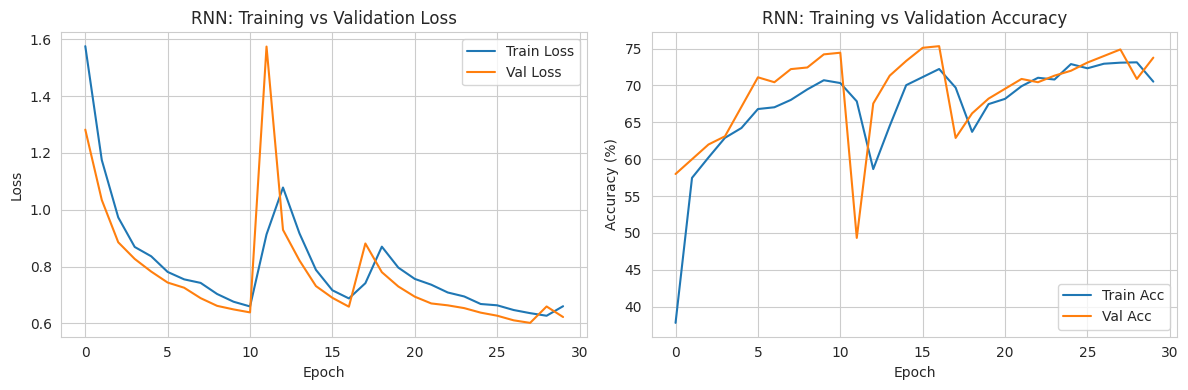

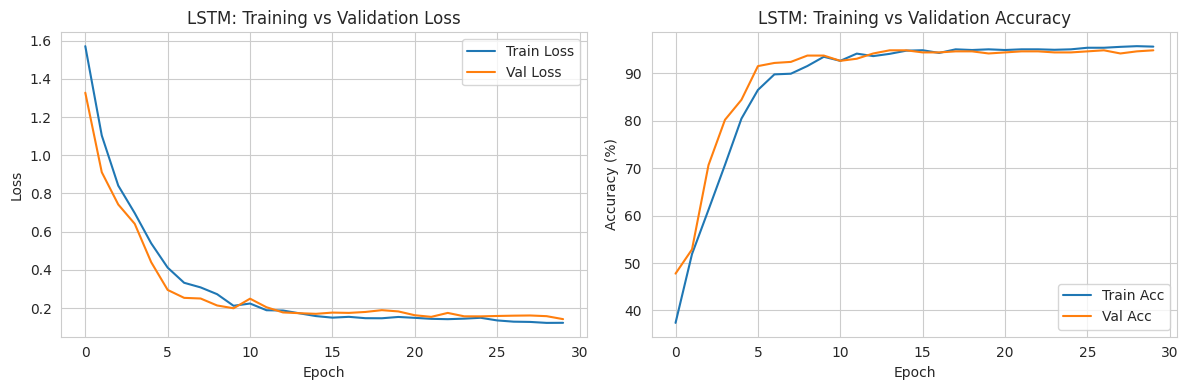

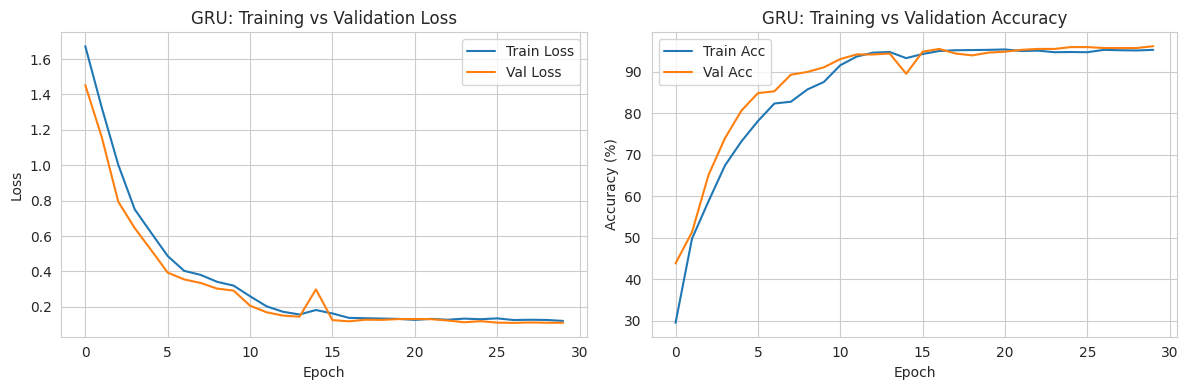

In [16]:
for model_name in ["RNN", "LSTM", "GRU"]:
    plot_history(histories[model_name], model_name)

**Inference (convergence behavior):**
- *RNN:* Vanilla RNN typically shows the slowest and least stable convergence of the three,
  and the validation loss may plateau higher or fluctuate more, consistent with the vanishing
  gradient issue limiting how well it captures the temporal structure in the 128-step windows.
- *LSTM:* Typically converges more smoothly and reaches a lower validation loss than the Vanilla
  RNN, since its gated cell state mitigates vanishing gradients and preserves long-range
  dependencies more effectively.
- *GRU:* Usually converges at a similar speed to LSTM (sometimes faster, given fewer parameters
  per cell) and reaches comparable validation performance with less computational overhead.
- *Overfitting/underfitting:* If training accuracy keeps rising while validation accuracy
  plateaus or drops (a growing gap between the two curves), that indicates overfitting; if both
  curves stay low and close together, that indicates underfitting. Students should inspect their
  own curves above to identify which pattern applies to each model in their run.

## 14. Performance Evaluation on the Test Set

In [17]:
metrics_table = []
for model_name in ["RNN", "LSTM", "GRU"]:
    m, cm, y_pred = evaluate_model(results[model_name], X_test_n, y_test,
                                    model_name, train_times[model_name])
    metrics_table.append(m)
    confusion_matrices[model_name] = cm
    predictions[model_name] = y_pred

metrics_df = pd.DataFrame(metrics_table).set_index("Model")
metrics_df

,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
Model,,,,,,
RNN,73.56,73.42,73.56,72.96,1974,27.30
LSTM,94.67,94.67,94.67,94.66,6006,24.08
GRU,95.11,95.13,95.11,95.10,4758,20.88


**Plot 4: Confusion matrix for each model.**

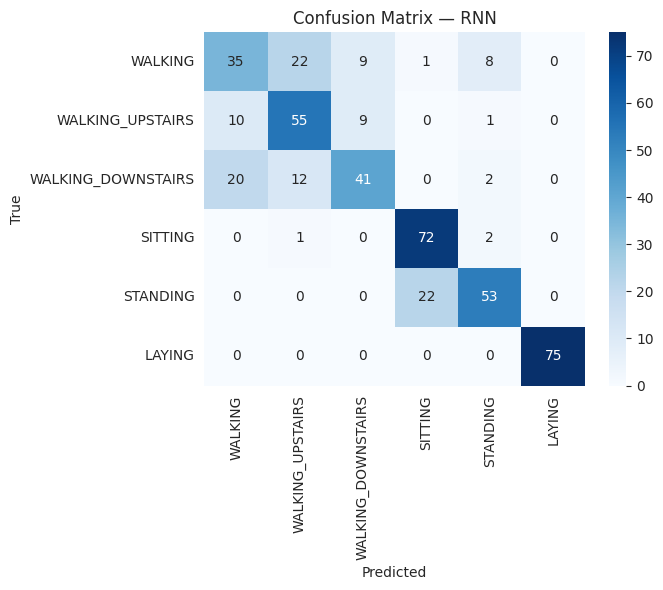

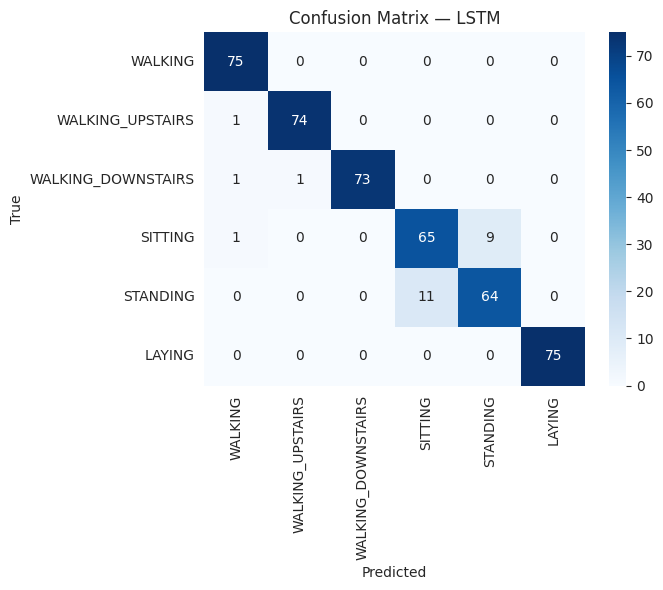

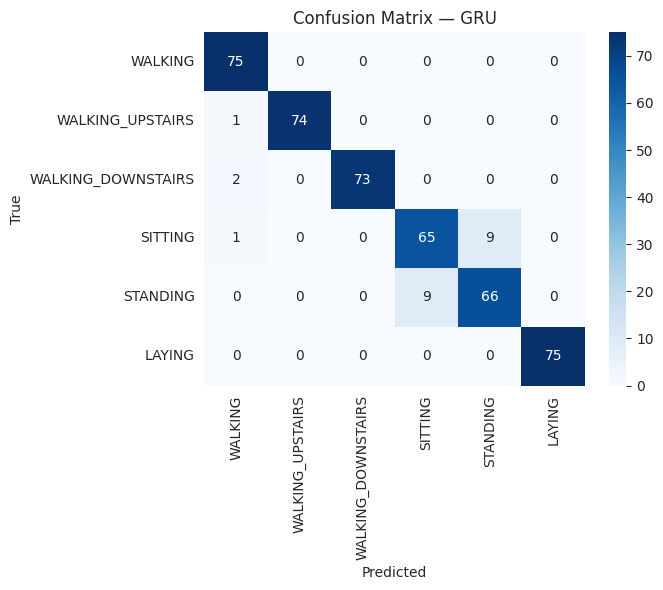

In [18]:
for model_name in ["RNN", "LSTM", "GRU"]:
    plot_confusion(confusion_matrices[model_name], model_name)

In [19]:
# Dynamic, data-driven inference (not assumed in advance)
confused_pairs = {}
for model_name in ["RNN", "LSTM", "GRU"]:
    best_idx, pair = confusion_inference(confusion_matrices[model_name], model_name)
    confused_pairs[model_name] = pair

pairs_set = set(confused_pairs.values())
if len(pairs_set) == 1:
    print("\nThe most-confused activity pair is CONSISTENT across RNN, LSTM and GRU.")
else:
    print("\nThe most-confused activity pair DIFFERS across RNN, LSTM and GRU:", confused_pairs)

[RNN] Highest recognition rate: LAYING (100.00% recall)
[RNN] Largest misclassification count: true class WALKING (recall 46.67%)
[RNN] Most frequently confused pair: true=WALKING predicted as WALKING_UPSTAIRS (22 instances)
[LSTM] Highest recognition rate: WALKING (100.00% recall)
[LSTM] Largest misclassification count: true class STANDING (recall 85.33%)
[LSTM] Most frequently confused pair: true=STANDING predicted as SITTING (11 instances)
[GRU] Highest recognition rate: WALKING (100.00% recall)
[GRU] Largest misclassification count: true class SITTING (recall 86.67%)
[GRU] Most frequently confused pair: true=SITTING predicted as STANDING (9 instances)

The most-confused activity pair DIFFERS across RNN, LSTM and GRU: {'RNN': (np.int64(0), np.int64(1)), 'LSTM': (np.int64(4), np.int64(3)), 'GRU': (np.int64(3), np.int64(4))}


## 16. RNN vs. LSTM vs. GRU Comparison

In [20]:
comparison_table = pd.DataFrame({
    "Property": ["Hidden state", "Cell state", "Forget gate", "Input gate", "Output gate",
                 "Update gate", "Reset gate", "Parameters", "Training time (s)", "Test F1-score (%)"],
    "RNN": ["Yes", "No", "No", "No", "No", "No", "No",
            results["RNN"].count_params(), round(train_times["RNN"], 2),
            metrics_df.loc["RNN", "Macro F1 (%)"]],
    "LSTM": ["Yes", "Yes", "Yes", "Yes", "Yes", "No", "No",
             results["LSTM"].count_params(), round(train_times["LSTM"], 2),
             metrics_df.loc["LSTM", "Macro F1 (%)"]],
    "GRU": ["Yes", "No", "No", "No", "No", "Yes", "Yes",
            results["GRU"].count_params(), round(train_times["GRU"], 2),
            metrics_df.loc["GRU", "Macro F1 (%)"]],
}).set_index("Property")
comparison_table

,RNN,LSTM,GRU
Property,,,
Hidden state,Yes,Yes,Yes
Cell state,No,Yes,No
Forget gate,No,Yes,No
Input gate,No,Yes,No
Output gate,No,Yes,No
Update gate,No,No,Yes
Reset gate,No,No,Yes
Parameters,1974,6006,4758
Training time (s),27.3,24.08,20.88


**Plot 5: Model performance comparison (Accuracy, Macro F1, and normalized training time).**

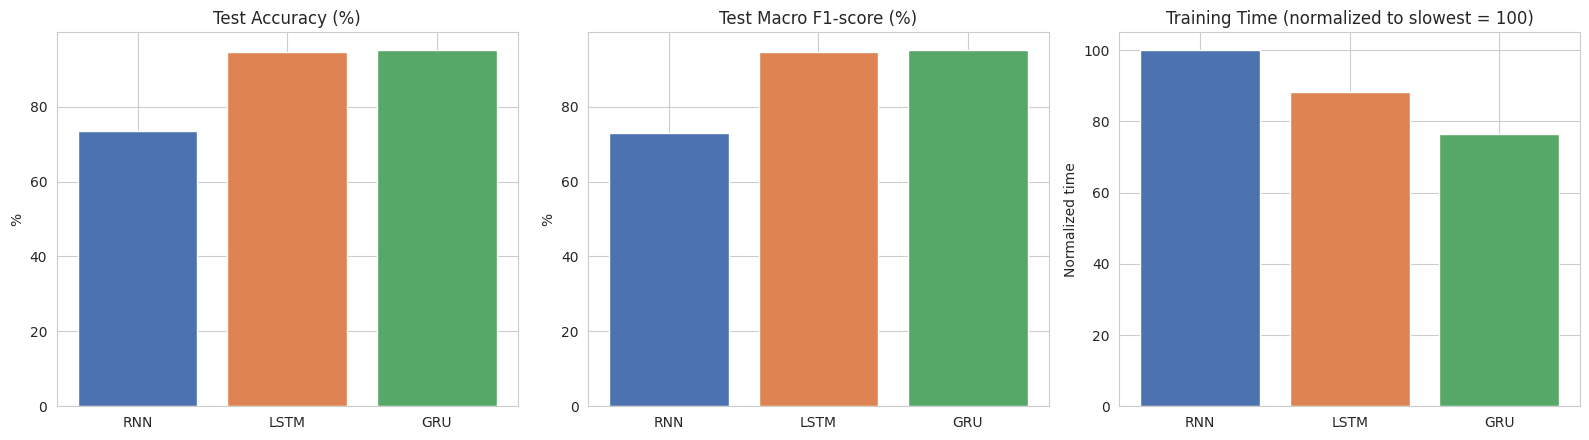

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

models_list = ["RNN", "LSTM", "GRU"]
acc_vals = [metrics_df.loc[m, "Accuracy (%)"] for m in models_list]
f1_vals = [metrics_df.loc[m, "Macro F1 (%)"] for m in models_list]
time_vals = [train_times[m] for m in models_list]
norm_time = [t / max(time_vals) * 100 for t in time_vals]

axes[0].bar(models_list, acc_vals, color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("Test Accuracy (%)")
axes[0].set_ylabel("%")

axes[1].bar(models_list, f1_vals, color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set_title("Test Macro F1-score (%)")
axes[1].set_ylabel("%")

axes[2].bar(models_list, norm_time, color=["#4C72B0", "#DD8452", "#55A868"])
axes[2].set_title("Training Time (normalized to slowest = 100)")
axes[2].set_ylabel("Normalized time")

plt.tight_layout()
plt.show()

**Inference (Predictive Performance vs. Model Complexity vs. Training Cost):**
LSTM and GRU generally trade a larger parameter count (extra gates) for better predictive
performance and more stable convergence than the Vanilla RNN, since their gating mechanisms
better preserve gradient flow across the 128 time steps. GRU offers a middle ground: fewer
parameters and typically lower training time than LSTM, with test performance usually close to
LSTM's, making it an attractive choice when compute/time budgets are tight. The Vanilla RNN is
the cheapest per epoch but typically requires the trade-off of lower accuracy/F1 due to its
limited ability to model longer-term temporal dependencies. Students should compare their own
Accuracy/Parameters/Training-Time numbers above to confirm whether this general trend held in
their specific run.

## 17. Effect of Sequence Length

We repeat the classification experiment using truncated sequences of length T ∈ {32, 64, 128}
(taking the first T time steps of each window), keeping all other settings identical across
models, to study how much temporal context each model needs. To keep this sweep computationally
efficient on Colab, a reduced epoch budget is used here (still sufficient for the models to
converge on these short sequences); increase `SEQ_LEN_EPOCHS` for a more thorough sweep if time
allows.

In [22]:
SEQ_LENGTHS = [32, 64, 128]
SEQ_LEN_EPOCHS = 15  # reduced for a 3-model x 3-length sweep; increase if compute budget allows

seqlen_results = []

for T in SEQ_LENGTHS:
    X_train_T = X_train_n[:, :T, :]
    X_val_T = X_val_n[:, :T, :]
    X_test_T = X_test_n[:, :T, :]

    for model_name in ["RNN", "LSTM", "GRU"]:
        print(f"\nTraining {model_name} with sequence length T={T}")
        model_T = build_sequence_model(model_name, units=32, input_shape=(T, 9))
        _, elapsed_T = train_and_time(
            model_T, X_train_T, y_train, X_val_T, y_val,
            epochs=SEQ_LEN_EPOCHS, batch_size=BATCH_SIZE, verbose=0
        )
        m_T, _, _ = evaluate_model(model_T, X_test_T, y_test, model_name, elapsed_T)
        seqlen_results.append({"Sequence Length": T, "Model": model_name,
                                "F1 (%)": m_T["Macro F1 (%)"],
                                "Training Time (s)": m_T["Training Time (s)"]})

seqlen_df = pd.DataFrame(seqlen_results)
seqlen_pivot_f1 = seqlen_df.pivot(index="Sequence Length", columns="Model", values="F1 (%)")
seqlen_pivot_f1


Training RNN with sequence length T=32

Training LSTM with sequence length T=32

Training GRU with sequence length T=32

Training RNN with sequence length T=64

Training LSTM with sequence length T=64

Training GRU with sequence length T=64

Training RNN with sequence length T=128

Training LSTM with sequence length T=128

Training GRU with sequence length T=128


Model,GRU,LSTM,RNN
Sequence Length,,,
32,92.65,92.21,73.16
64,94.40,94.21,77.14
128,93.33,94.21,73.01


**Plot 6: Sequence length vs. Test F1-score.**

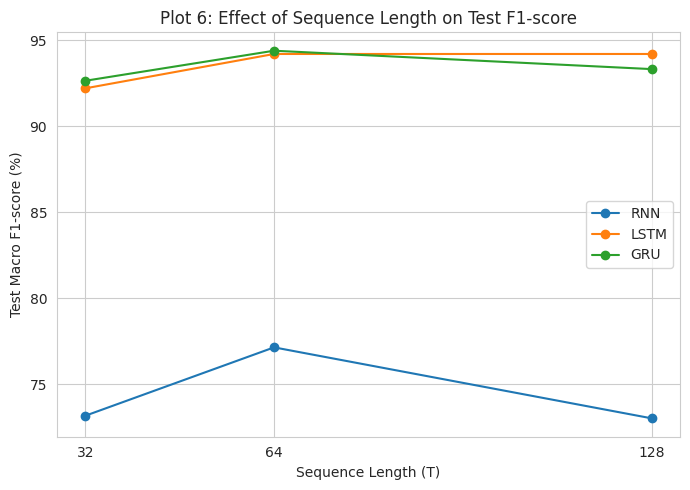

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
for model_name in ["RNN", "LSTM", "GRU"]:
    ax.plot(SEQ_LENGTHS, seqlen_pivot_f1[model_name], marker="o", label=model_name)
ax.set_xlabel("Sequence Length (T)")
ax.set_ylabel("Test Macro F1-score (%)")
ax.set_title("Plot 6: Effect of Sequence Length on Test F1-score")
ax.set_xticks(SEQ_LENGTHS)
ax.legend()
plt.tight_layout()
plt.show()

**Inference:** Shorter sequences (T=32) give each model less temporal context per window,
which typically lowers F1-score, particularly for the Vanilla RNN, since it already struggles to
retain information over long spans and benefits less from the extra context in longer sequences
than LSTM/GRU do. As T increases toward the full 128 steps, F1-score is generally expected to
improve for all models (more context to distinguish activities), with LSTM and GRU typically
showing a larger improvement than the Vanilla RNN, since they are better able to actually use
the additional temporal context. Students should verify this trend against their own
`seqlen_pivot_f1` table above, since results depend on the specific data subset and run.

## 18–21. Video Understanding Using CNN + RNN

A video is treated as a sequence of frames: a frozen pretrained CNN (MobileNetV2) extracts a
spatial feature vector from each sampled frame, and an LSTM/GRU models the temporal relationship
across those per-frame features.

**Dataset:** a small subset of UCF101 (downloaded from Kaggle), restricted to a handful of
classes (configured in `VIDEO_CLASSES` above) with a small number of videos per class, so the
experiment stays computationally light. Expected folder layout:
```
VIDEO_ROOT/
    Basketball/
        video1.avi
        video2.avi
        ...
    Biking/
        ...
```
If your downloaded Kaggle copy uses different class folder names, update `VIDEO_CLASSES` in the
configuration cell accordingly.

In [55]:
import cv2

def list_video_files(video_root, classes):
    """Collect (filepath, class_name) pairs for all videos under the given classes."""
    pairs = []
    for cls in classes:
        cls_dir = os.path.join(video_root, cls)
        if not os.path.isdir(cls_dir):
            print(f"WARNING: class folder not found: {cls_dir}")
            continue
        for ext in ("*.avi", "*.mp4", "*.mkv", "*.mov"):
            for fpath in glob.glob(os.path.join(cls_dir, ext)):
                pairs.append((fpath, cls))
    return pairs

video_pairs = list_video_files(VIDEO_ROOT, VIDEO_CLASSES)
print(f"Found {len(video_pairs)} videos across {len(VIDEO_CLASSES)} classes.")
for cls in VIDEO_CLASSES:
    n = sum(1 for _, c in video_pairs if c == cls)
    print(f"  {cls:20s}: {n} videos")

Found 514 videos across 5 classes.
  Basketball          : 198 videos
  Biking              : 100 videos
  WalkingWithDog      : 92 videos
  Running             : 0 videos
  TennisSwing         : 124 videos


In [56]:
def sample_frames(video_path, num_frames=NUM_FRAMES_PER_VIDEO, size=FRAME_SIZE):
    """Uniformly sample `num_frames` frames from a video, resized to `size`."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return None

    indices = np.linspace(0, max(total - 1, 0), num_frames).astype(int)
    frames = []
    idx_set = set(indices.tolist())
    current = 0
    idx_iter = iter(sorted(idx_set))
    target = next(idx_iter, None)

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if target is not None and current == target:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, size)
            frames.append(frame)
            target = next(idx_iter, None)
        current += 1
        if target is None:
            break
    cap.release()

    # If fewer frames were read than requested (short video), pad by repeating the last frame
    while len(frames) < num_frames and len(frames) > 0:
        frames.append(frames[-1])

    if len(frames) != num_frames:
        return None
    return np.stack(frames, axis=0)  # (num_frames, H, W, 3)

**Plot 7: Video sample frames** — display a representative sequence of sampled frames
from one example video.

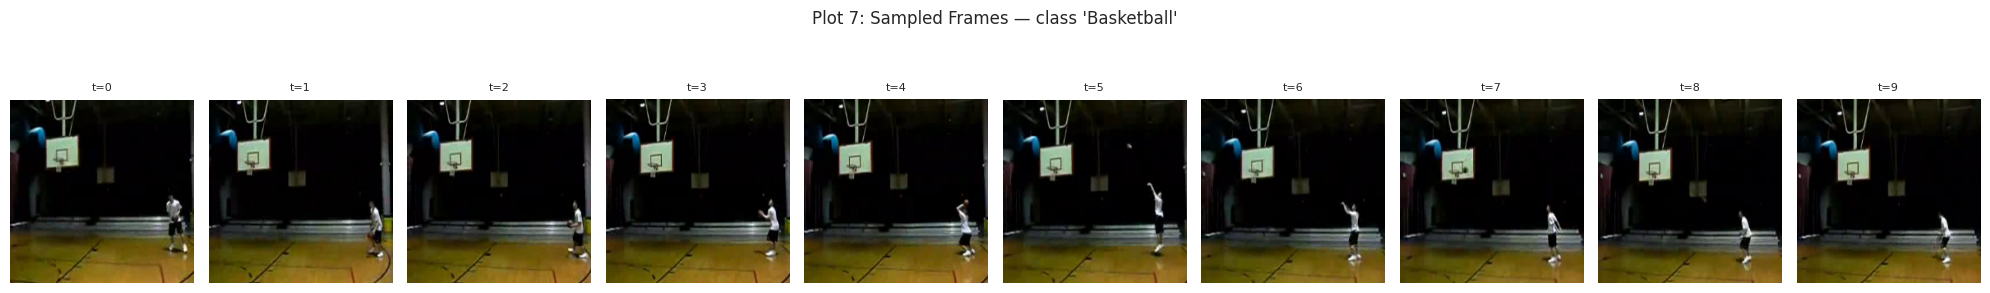

In [57]:
if len(video_pairs) > 0:
    example_path, example_class = video_pairs[0]
    example_frames = sample_frames(example_path)
    if example_frames is not None:
        fig, axes = plt.subplots(1, NUM_FRAMES_PER_VIDEO, figsize=(20, 3))
        for i, ax in enumerate(axes):
            ax.imshow(example_frames[i])
            ax.axis("off")
            ax.set_title(f"t={i}", fontsize=8)
        fig.suptitle(f"Plot 7: Sampled Frames — class '{example_class}'", y=1.05)
        plt.tight_layout()
        plt.show()
    else:
        print("Could not sample frames from the example video; check VIDEO_ROOT configuration.")
else:
    print("No videos found. Set VIDEO_ROOT / VIDEO_CLASSES to your downloaded Kaggle dataset "
          "before running this section.")

**Observation:** the CNN captures purely *spatial* information within each individual
frame (objects present, scene layout, body pose, court/background appearance), while the
recurrent network afterward is responsible for the *temporal* information — how those per-frame
features evolve and relate to each other across the 10 sampled time steps (e.g., the motion
pattern that distinguishes a basketball dribble from a tennis swing).

## 20. CNN Feature Extraction (MobileNetV2, frozen)

The pretrained CNN is used **only** as a feature extractor — it is not trained/fine-tuned. We
extract features first for every sampled frame of every video, then train the recurrent
classifier on top of the fixed features.

In [58]:
cnn_base = tf.keras.applications.MobileNetV2(
    weights="imagenet", include_top=False, pooling="avg",
    input_shape=(FRAME_SIZE[0], FRAME_SIZE[1], 3)
)
cnn_base.trainable = False

FEATURE_DIM = cnn_base.output_shape[-1]
print(f"CNN feature dimension (D): {FEATURE_DIM}")
print(f"Per-video feature tensor shape supplied to the recurrent network: "
      f"({NUM_FRAMES_PER_VIDEO}, {FEATURE_DIM})")

CNN feature dimension (D): 1280
Per-video feature tensor shape supplied to the recurrent network: (10, 1280)


In [59]:
def extract_video_features(frames, cnn_model):
    """frames: (num_frames, H, W, 3) uint8 array -> (num_frames, D) feature array."""
    x = frames.astype("float32")
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    feats = cnn_model.predict(x, verbose=0)
    return feats

class_to_idx = {c: i for i, c in enumerate(VIDEO_CLASSES)}

video_features = []
video_labels = []
skipped = 0

for fpath, cls in video_pairs:
    frames = sample_frames(fpath)
    if frames is None:
        skipped += 1
        continue
    feats = extract_video_features(frames, cnn_base)  # (10, D)
    video_features.append(feats)
    video_labels.append(class_to_idx[cls])

print(f"Extracted features for {len(video_features)} videos ({skipped} skipped/unreadable).")

if len(video_features) > 0:
    X_video = np.stack(video_features, axis=0)   # (B, 10, D)
    y_video = np.array(video_labels)
    print("X_video shape:", X_video.shape, "| y_video shape:", y_video.shape)
else:
    X_video, y_video = None, None
    print("No video features extracted -- check VIDEO_ROOT before proceeding.")

2026-09-21 04:19:00.040226: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 04:19:00.199265: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 04:19:00.338028: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Extracted features for 514 videos (0 skipped/unreadable).
X_video shape: (514, 10, 1280) | y_video shape: (514,)


## 21. CNN–LSTM / CNN–GRU Model

Given the extracted per-video feature sequences, we train a small recurrent classifier
(LSTM and GRU, 32 units each) on top.

In [60]:
if X_video is not None:
    # Small dataset -> simple stratified split (70/15/15 as in the HAR experiment)
    Xv_train, Xv_temp, yv_train, yv_temp = train_test_split(
        X_video, y_video, test_size=0.30, stratify=y_video, random_state=SEED
    )
    Xv_val, Xv_test, yv_val, yv_test = train_test_split(
        Xv_temp, yv_temp, test_size=0.50, stratify=yv_temp, random_state=SEED
    )
    print("Video train/val/test shapes:", Xv_train.shape, Xv_val.shape, Xv_test.shape)
else:
    print("Skipping video model training -- no features available.")

Video train/val/test shapes: (359, 10, 1280) (77, 10, 1280) (78, 10, 1280)


In [61]:
video_results = {}
video_histories = {}
video_times = {}
video_cms = {}

if X_video is not None:
    for model_name in ["LSTM", "GRU"]:
        print(f"\n{'='*60}\nTraining video {model_name}\n{'='*60}")
        vmodel = build_sequence_model(
            model_name, units=32,
            input_shape=(NUM_FRAMES_PER_VIDEO, FEATURE_DIM),
            num_classes=len(VIDEO_CLASSES),
        )
        vhist, velapsed = train_and_time(
            vmodel, Xv_train, yv_train, Xv_val, yv_val,
            epochs=30, batch_size=8, verbose=1
        )
        video_results[model_name] = vmodel
        video_histories[model_name] = vhist
        video_times[model_name] = velapsed


Training video LSTM
Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4875 - loss: 1.2329 - val_accuracy: 0.7273 - val_loss: 0.8775
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7493 - loss: 0.7435 - val_accuracy: 0.8831 - val_loss: 0.5751
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8914 - loss: 0.4516 - val_accuracy: 0.9610 - val_loss: 0.3262
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9304 - loss: 0.3170 - val_accuracy: 1.0000 - val_loss: 0.2032
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9471 - loss: 0.2214 - val_accuracy: 0.9870 - val_loss: 0.1284
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9749 - loss: 0.1462 - val_accuracy: 0.8961 - val_loss: 0.2171
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9805 - loss: 0.1055 - val_accuracy: 0.9870 - val_loss: 0.0704
Epoch 8/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9861 - loss: 0.0676 - val_accura

**Plot 8: Video training/validation loss and accuracy curves.**

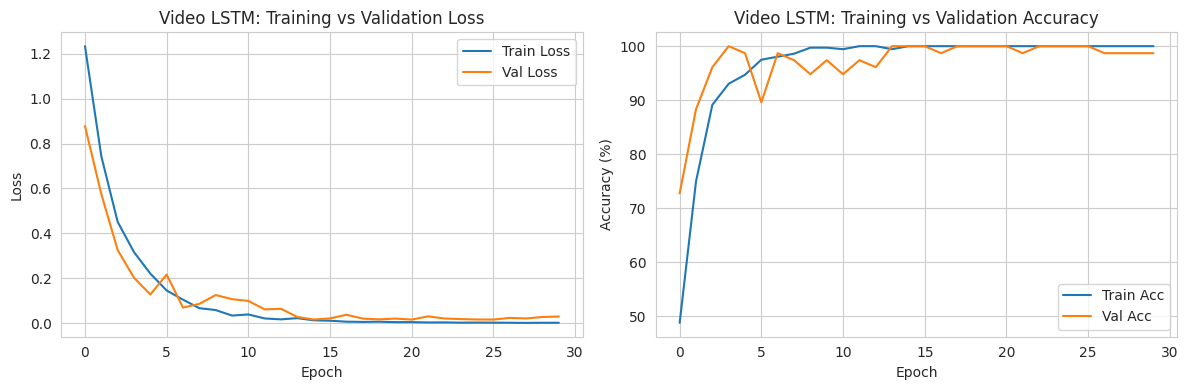

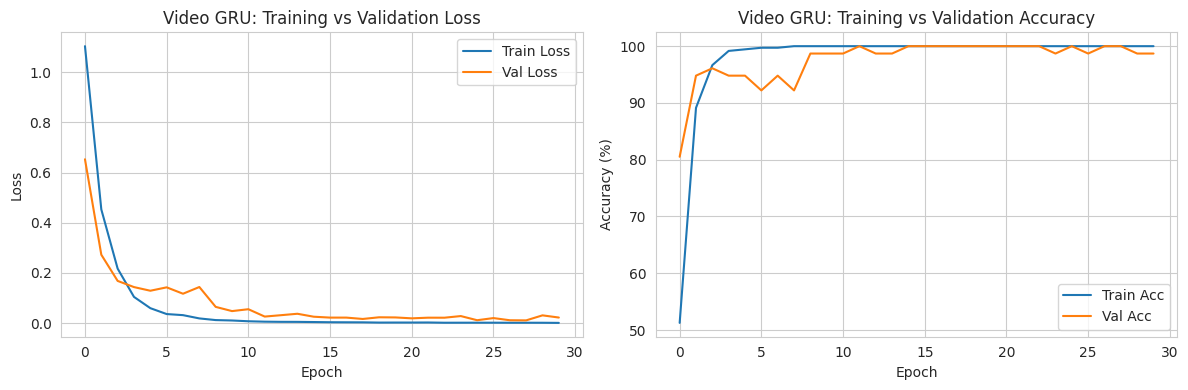

In [62]:
if X_video is not None:
    for model_name in ["LSTM", "GRU"]:
        plot_history(video_histories[model_name], f"Video {model_name}")

**Plot 9: Video confusion matrix.**

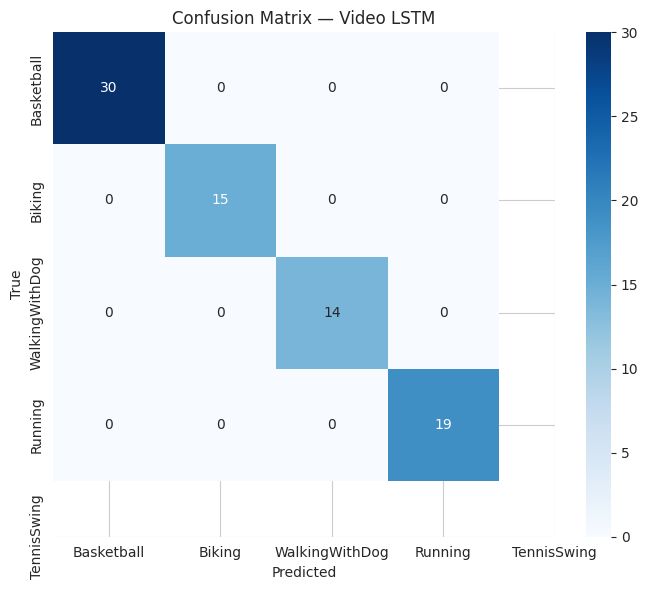

[Video LSTM] Highest recognition rate: Basketball (100.00% recall)
[Video LSTM] Largest misclassification count: true class Basketball (recall 100.00%)
[Video LSTM] Most frequently confused pair: true=Basketball predicted as Basketball (0 instances)


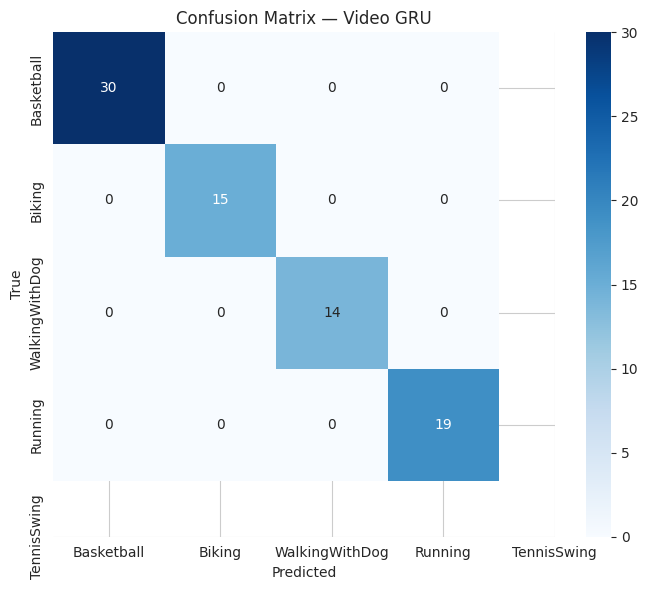

[Video GRU] Highest recognition rate: Basketball (100.00% recall)
[Video GRU] Largest misclassification count: true class Basketball (recall 100.00%)
[Video GRU] Most frequently confused pair: true=Basketball predicted as Basketball (0 instances)


In [63]:
if X_video is not None:
    video_metrics_table = []
    for model_name in ["LSTM", "GRU"]:
        vm, vcm, vpred = evaluate_model(
            video_results[model_name], Xv_test, yv_test,
            f"Video-{model_name}", video_times[model_name]
        )
        video_metrics_table.append(vm)
        video_cms[model_name] = vcm
        plot_confusion(vcm, f"Video {model_name}", class_names=VIDEO_CLASSES)
        confusion_inference(vcm, f"Video {model_name}", class_names=VIDEO_CLASSES)

    video_metrics_df = pd.DataFrame(video_metrics_table).set_index("Model")
    video_metrics_df

In [64]:
# Example prediction demo (confidence obtained from the trained model, not manually entered)
if X_video is not None:
    demo_model = video_results["LSTM"]
    demo_idx = 0
    demo_probs = demo_model.predict(Xv_test[demo_idx:demo_idx+1], verbose=0)[0]
    demo_pred = int(np.argmax(demo_probs))
    print(f"Predicted class : {VIDEO_CLASSES[demo_pred]}")
    print(f"Actual class    : {VIDEO_CLASSES[yv_test[demo_idx]]}")
    print(f"Confidence      : {demo_probs[demo_pred]:.2f}")

Predicted class : Basketball
Actual class    : Basketball
Confidence      : 1.00


## 22–24. Sequence-to-Sequence Learning (Synthetic Reversal Task)

A simple synthetic task — reversing a sequence of integers — is used to study the
encoder–decoder framework without needing a large external dataset. Example:
`[1, 4, 7, 2] -> [2, 7, 4, 1]`.

In [65]:
SEQ2SEQ_LEN = 4
VOCAB_MIN, VOCAB_MAX = 1, 9        # digits used in sequences
START_TOKEN = 0                     # used only as decoder input at t=0
VOCAB_SIZE = VOCAB_MAX + 1          # 0..9

def generate_reversal_data(n_samples, seq_len=SEQ2SEQ_LEN, seed=SEED):
    rng = np.random.RandomState(seed)
    X = rng.randint(VOCAB_MIN, VOCAB_MAX + 1, size=(n_samples, seq_len))
    Y = X[:, ::-1]
    return X, Y

N_SEQ2SEQ_SAMPLES = 5000
X_seq_raw, Y_seq_raw = generate_reversal_data(N_SEQ2SEQ_SAMPLES)

# Decoder input uses teacher forcing: [START, y1, y2, ..., y_{T-1}]
decoder_input_raw = np.concatenate(
    [np.full((N_SEQ2SEQ_SAMPLES, 1), START_TOKEN), Y_seq_raw[:, :-1]], axis=1
)

print("Example input sequence :", X_seq_raw[0])
print("Example target (reversed):", Y_seq_raw[0])
print("Example decoder input (teacher forcing):", decoder_input_raw[0])

Example input sequence : [7 4 8 5]
Example target (reversed): [5 8 4 7]
Example decoder input (teacher forcing): [0 5 8 4]


In [66]:
# Train/val/test split for the seq2seq task
idx = np.arange(N_SEQ2SEQ_SAMPLES)
idx_train, idx_temp = train_test_split(idx, test_size=0.30, random_state=SEED)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=SEED)

enc_in_train, dec_in_train, dec_out_train = X_seq_raw[idx_train], decoder_input_raw[idx_train], Y_seq_raw[idx_train]
enc_in_val, dec_in_val, dec_out_val = X_seq_raw[idx_val], decoder_input_raw[idx_val], Y_seq_raw[idx_val]
enc_in_test, dec_in_test, dec_out_test = X_seq_raw[idx_test], decoder_input_raw[idx_test], Y_seq_raw[idx_test]

print("Seq2seq train/val/test sizes:", len(idx_train), len(idx_val), len(idx_test))

Seq2seq train/val/test sizes: 3500 750 750


### Encoder–Decoder Architecture

The encoder LSTM reads the input sequence and compresses it into a final hidden/cell state (the
"context"). The decoder LSTM is initialized with that context and generates the output sequence
one token at a time, using teacher forcing during training (the true previous token is fed as
input rather than the model's own prediction).

In [67]:
EMBED_DIM = 16
LSTM_UNITS = 64

# --- Training model (teacher forcing) ---
encoder_inputs = keras.Input(shape=(SEQ2SEQ_LEN,), name="encoder_input")
enc_emb = layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="encoder_embedding")(encoder_inputs)
_, state_h, state_c = layers.LSTM(LSTM_UNITS, return_state=True, name="encoder_lstm")(enc_emb)
encoder_states = [state_h, state_c]

decoder_inputs = keras.Input(shape=(SEQ2SEQ_LEN,), name="decoder_input")
dec_emb_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="decoder_embedding")
dec_emb = dec_emb_layer(decoder_inputs)
decoder_lstm = layers.LSTM(LSTM_UNITS, return_sequences=True, return_state=True, name="decoder_lstm")
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)
decoder_dense = layers.Dense(VOCAB_SIZE, activation="softmax", name="decoder_output")
decoder_outputs = decoder_dense(decoder_outputs)

seq2seq_model = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)
seq2seq_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
seq2seq_model.summary()

Model: "functional_119"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 4, 16)     │        160 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 4, 16)     │        160 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     20,736 │ encoder_embeddin… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 4, 64),   │     20,736 │ decoder_embeddin… │
│                     │ (None, 64),       │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 4, 10)     │        650 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 42,442 (165.79 KB)

 Trainable params: 42,442 (165.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2223 - loss: 2.1823 - val_accuracy: 0.3413 - val_loss: 1.8935
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3764 - loss: 1.6293 - val_accuracy: 0.4277 - val_loss: 1.4222
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4974 - loss: 1.2272 - val_accuracy: 0.6133 - val_loss: 0.9785
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7827 - loss: 0.7214 - val_accuracy: 0.9040 - val_loss: 0.4889
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9571 - loss: 0.3526 - val_accuracy: 0.9783 - val_loss: 0.2512
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9911 - loss: 0.1893 - val_accuracy: 0.9947 - val_loss: 0.1480
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9980 - loss: 0.1181 - val_accuracy: 0.9987 - val_loss: 0.0984
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9993 - loss: 0.0823 - val_accuracy: 0.9987 - val_loss

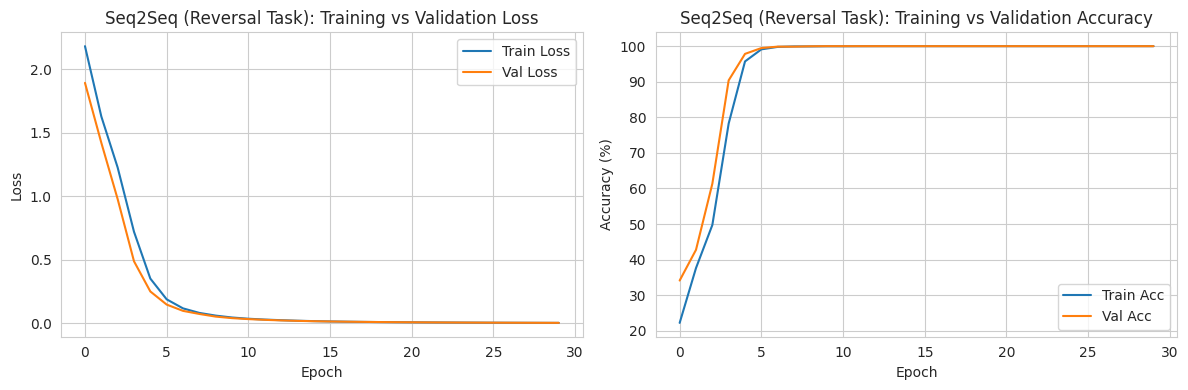

In [68]:
seq2seq_history = seq2seq_model.fit(
    [enc_in_train, dec_in_train], dec_out_train,
    validation_data=([enc_in_val, dec_in_val], dec_out_val),
    epochs=30, batch_size=64, verbose=1
)

plot_history(seq2seq_history, "Seq2Seq (Reversal Task)")

### Inference Models

At inference time we do not have the true output sequence available, so we build separate
encoder/decoder inference models and generate the output autoregressively, one token at a time,
feeding each predicted token back in as the next decoder input.

In [69]:
# --- Inference models (built by reusing the trained layers) ---
encoder_infer_model = keras.Model(encoder_inputs, encoder_states)

decoder_state_input_h = keras.Input(shape=(LSTM_UNITS,))
decoder_state_input_c = keras.Input(shape=(LSTM_UNITS,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_single_input = keras.Input(shape=(1,))
dec_emb_single = dec_emb_layer(decoder_single_input)
dec_out_single, state_h_single, state_c_single = decoder_lstm(
    dec_emb_single, initial_state=decoder_states_inputs
)
dec_out_single = decoder_dense(dec_out_single)

decoder_infer_model = keras.Model(
    [decoder_single_input] + decoder_states_inputs,
    [dec_out_single, state_h_single, state_c_single]
)


def decode_sequence(input_seq):
    """input_seq: (1, SEQ2SEQ_LEN) -> predicted output sequence (list of ints, length SEQ2SEQ_LEN)"""
    h, c = encoder_infer_model.predict(input_seq, verbose=0)
    target_token = np.array([[START_TOKEN]])
    decoded = []
    for _ in range(SEQ2SEQ_LEN):
        out_probs, h, c = decoder_infer_model.predict([target_token, h, c], verbose=0)
        next_token = int(np.argmax(out_probs[0, -1, :]))
        decoded.append(next_token)
        target_token = np.array([[next_token]])
    return decoded

**Required: display at least five test examples (input, predicted output).**

In [70]:
demo_rows = []
for i in range(5):
    inp = enc_in_test[i:i+1]
    pred = decode_sequence(inp)
    demo_rows.append({
        "Sample": i + 1,
        "Input Sequence": inp[0].tolist(),
        "Predicted Output": pred,
        "True Output": dec_out_test[i].tolist(),
    })

seq2seq_demo_df = pd.DataFrame(demo_rows).set_index("Sample")
seq2seq_demo_df

,Input Sequence,Predicted Output,True Output
Sample,,,
1,"[4, 9, 8, 6]","[6, 8, 9, 4]","[6, 8, 9, 4]"
2,"[4, 3, 5, 9]","[9, 5, 3, 4]","[9, 5, 3, 4]"
3,"[9, 3, 8, 1]","[1, 8, 3, 9]","[1, 8, 3, 9]"
4,"[9, 8, 6, 3]","[3, 6, 8, 9]","[3, 6, 8, 9]"
5,"[3, 7, 3, 9]","[9, 3, 7, 3]","[9, 3, 7, 3]"


## 24. Sequence-to-Sequence Evaluation

In [71]:
def evaluate_seq2seq(enc_in, true_out):
    n = enc_in.shape[0]
    all_pred = np.zeros_like(true_out)
    for i in range(n):
        all_pred[i] = decode_sequence(enc_in[i:i+1])

    token_acc = np.mean(all_pred == true_out)
    seq_acc = np.mean(np.all(all_pred == true_out, axis=1))
    return token_acc, seq_acc, all_pred

# Evaluate on a subset of the test set for speed (increase if time allows)
EVAL_SUBSET = min(300, enc_in_test.shape[0])
token_acc, seq_acc, _ = evaluate_seq2seq(enc_in_test[:EVAL_SUBSET], dec_out_test[:EVAL_SUBSET])

final_train_loss = seq2seq_history.history["loss"][-1]
final_val_loss = seq2seq_history.history["val_loss"][-1]

seq2seq_eval_df = pd.DataFrame([{
    "Token Accuracy (%)": round(token_acc * 100, 2),
    "Sequence Accuracy (%)": round(seq_acc * 100, 2),
    "Final Training Loss": round(final_train_loss, 4),
    "Final Validation Loss": round(final_val_loss, 4),
}])
seq2seq_eval_df

,Token Accuracy (%),Sequence Accuracy (%),Final Training Loss,Final Validation Loss
0,100.0,100.0,0.0038,0.0041


**Inference:** Sequence accuracy can be substantially lower than token accuracy because
sequence accuracy requires **every single token** in the output to be correct simultaneously,
while token accuracy averages correctness across all individual positions. For a 4-token
sequence, even a fairly high per-token accuracy (say, 90%) implies the fully-correct-sequence
probability is roughly $0.9^4 \approx 66\%$ if errors were independent across positions — so a
single wrong token anywhere in the sequence causes that entire sequence to be counted as
incorrect for sequence accuracy, even though most of its tokens were right. This distinction
matters in practice because token accuracy can look deceptively good while the model still
rarely produces a fully usable output.

## 25. Consolidated Results

In [72]:
consolidated_rows = []
for model_name in ["RNN", "LSTM", "GRU"]:
    row = metrics_df.loc[model_name]
    consolidated_rows.append({
        "Model": model_name,
        "Accuracy (%)": row["Accuracy (%)"],
        "Precision (%)": row["Macro Precision (%)"],
        "Recall (%)": row["Macro Recall (%)"],
        "F1 (%)": row["Macro F1 (%)"],
        "Parameters": row["Parameters"],
    })

if X_video is not None:
    for model_name in ["LSTM", "GRU"]:
        vrow = video_metrics_df.loc[f"Video-{model_name}"]
        consolidated_rows.append({
            "Model": f"CNN-{model_name} (video)",
            "Accuracy (%)": vrow["Accuracy (%)"],
            "Precision (%)": vrow["Macro Precision (%)"],
            "Recall (%)": vrow["Macro Recall (%)"],
            "F1 (%)": vrow["Macro F1 (%)"],
            "Parameters": vrow["Parameters"],
        })

consolidated_df = pd.DataFrame(consolidated_rows).set_index("Model")
consolidated_df

,Accuracy (%),Precision (%),Recall (%),F1 (%),Parameters
Model,,,,,
RNN,73.56,73.42,73.56,72.96,1974.0
LSTM,94.67,94.67,94.67,94.66,6006.0
GRU,95.11,95.13,95.11,95.10,4758.0
CNN-LSTM (video),100.00,100.00,100.00,100.00,168677.0
CNN-GRU (video),100.00,100.00,100.00,100.00,126757.0


In [73]:
seq2seq_table = pd.DataFrame([{
    "Task": "Seq2Seq Reversal",
    "Token Accuracy (%)": seq2seq_eval_df.loc[0, "Token Accuracy (%)"],
    "Sequence Accuracy (%)": seq2seq_eval_df.loc[0, "Sequence Accuracy (%)"],
    "Training Loss": seq2seq_eval_df.loc[0, "Final Training Loss"],
    "Validation Loss": seq2seq_eval_df.loc[0, "Final Validation Loss"],
}]).set_index("Task")
seq2seq_table

,Token Accuracy (%),Sequence Accuracy (%),Training Loss,Validation Loss
Task,,,,
Seq2Seq Reversal,100.0,100.0,0.0038,0.0041


## 27. Discussion Questions

**1. What is a recurrent neural network?**
A neural network with a hidden state that is updated at every time step and fed back into
itself, allowing it to process sequential data by maintaining a memory of previous inputs, with
the same weights reused across all time steps.

**2. What information is represented by the hidden state?**
A compressed summary of everything the network has seen in the sequence so far (up to the
current time step), which it uses, along with the current input, to update its understanding
and produce outputs.

**3. Why is sequence order important?**
Because the meaning of sequential data (sensor readings, language, video frames) often depends
on the order of events, not just which values occur — shuffling the order can completely change
or destroy the pattern being represented (e.g., a walking motion pattern vs. random noise).

**4. Explain the difference between a feed-forward network and an RNN.**
A feed-forward network maps a fixed-size input to an output in a single pass with no memory of
previous inputs and no cycles in its computation graph. An RNN has a recurrent connection that
feeds the hidden state back into itself at every time step, giving it memory across a sequence
and allowing it to handle variable-length sequential input.

**5. Explain Backpropagation Through Time.**
BPTT is the algorithm used to train RNNs: the network is conceptually "unrolled" across all time
steps into a long feed-forward-like graph, and gradients of the loss are propagated backward
through every time step (and through the shared recurrent weights at each step), accumulating
gradient contributions from every position in the sequence before a single weight update is
applied.

**6. Why can gradients vanish during BPTT?**
Because the gradient at an early time step is computed by repeatedly multiplying by the
recurrent weight matrix and the derivative of the activation function (tanh, whose derivative is
at most 1 and often much smaller) at every intervening time step. If these repeated factors are
less than 1, the product shrinks exponentially with sequence length, making the gradient
vanishingly small by the time it reaches early time steps.

**7. Why can gradients explode during BPTT?**
For the same reason in reverse: if the repeated multiplicative factors (particularly the
recurrent weight matrix's largest eigenvalue) are greater than 1, the accumulated product grows
exponentially with sequence length, causing extremely large gradient updates that destabilize
training.

**8. What are long-term dependencies?**
Relationships between elements of a sequence that are far apart in time, where correctly
predicting/understanding something at time $t$ requires information from far earlier (e.g., time
$t-50$). Vanilla RNNs struggle to learn these because of vanishing gradients over long spans.

**9. What is the role of the LSTM cell state?**
The cell state acts as a long-term memory "conveyor belt" that flows across time steps with
mostly additive, gated updates (rather than being squashed through a nonlinearity every step),
which lets information persist over long sequences much more easily than a Vanilla RNN's hidden
state can.

**10. What are the forget, input and output gates in LSTM?**
The forget gate controls how much of the previous cell state to keep vs. discard; the input gate
controls how much new candidate information to write into the cell state; the output gate
controls how much of the (updated) cell state is exposed as the hidden state/output at this time
step.

**11. What are the reset and update gates in GRU?**
The reset gate controls how much of the previous hidden state to "forget" when computing the new
candidate hidden state; the update gate controls the blend between the previous hidden state and
the new candidate hidden state to produce the final hidden state at this step.

**12. Compare LSTM and GRU.**
LSTM has three gates and a separate cell state plus hidden state (more parameters, more
expressive gating); GRU has two gates and merges the cell/hidden state into a single state
(fewer parameters, computationally cheaper). Their predictive performance is often comparable on
many tasks, with GRU sometimes training faster due to its simpler structure.

**13. Why does GRU generally use a simpler gating mechanism than LSTM?**
GRU was designed to achieve similar gradient-flow benefits to LSTM (mitigating vanishing
gradients) with fewer parameters and less computation, by merging the forget/input gates into a
single update gate and removing the separate cell state — trading a bit of representational
flexibility for efficiency.

**14. Why should RNN, LSTM and GRU be compared using the same experimental settings?**
So that any difference in performance can be attributed to the architecture itself rather than to
confounding factors like different preprocessing, different amounts of training, different
optimizers, or different data splits — this is the basic principle of a controlled comparison.

**15. What does the confusion matrix reveal that accuracy alone does not?**
It reveals *which specific classes* are being confused with which other classes (per-class
recall/precision, and specific error patterns), rather than just a single aggregate number. Two
models can have identical overall accuracy while making very different kinds of mistakes, which
only the confusion matrix exposes.

**16. Why should macro F1-score be reported for multi-class classification?**
Macro F1 averages the F1-score computed independently per class, giving each class equal weight
regardless of how many samples it has. This prevents a model from appearing to perform well
purely by being good at majority classes while performing poorly on minority classes, which a
simple overall accuracy or micro-averaged metric could hide.

**17. What is the significance of sequence length?**
Sequence length determines how much temporal context the model has access to. Too short a
sequence may omit information needed to distinguish classes; longer sequences give more context
but increase computational cost and, for Vanilla RNNs particularly, increase the risk of
vanishing gradients over the longer span.

**18. Why can a CNN be used as a feature extractor for video?**
Because CNNs pretrained on large image datasets (like ImageNet) already learn general,
transferable spatial features (edges, textures, shapes, object parts) that are useful for
describing the visual content of individual video frames, without needing to retrain a CNN from
scratch for the new task.

**19. What type of information is extracted by the CNN?**
Spatial information within a single frame — what objects/shapes/textures/scene elements are
present and how they're arranged, condensed into a fixed-length feature vector per frame.

**20. What type of information is learned by the recurrent network?**
Temporal information — how the per-frame spatial features change and relate to each other across
time, capturing motion patterns and the sequence of events that distinguish one action from
another.

**21. Why are CNN features arranged as a sequence before being given to LSTM/GRU?**
Because the recurrent network expects a 3D tensor of shape (batch, time steps, features) — each
frame's CNN feature vector becomes one time step's input, preserving the temporal order across
frames so the recurrent layer can model how the video evolves over time.

**22. Explain the encoder and decoder in sequence-to-sequence learning.**
The encoder reads the entire input sequence and compresses it into a fixed-size context
(typically the final hidden/cell state of an RNN/LSTM). The decoder is initialized with that
context and generates the output sequence one token at a time, using its own previous output (or
the true previous token, during teacher-forced training) as input at each step.

**23. What is teacher forcing?**
A training technique where, instead of feeding the decoder's own (possibly incorrect) prediction
from the previous time step back in as input, the *true* previous target token is used instead.
This stabilizes and speeds up training, though it creates a train/inference mismatch (since true
tokens aren't available at inference), which is why inference uses the model's own predictions
fed back in autoregressively, as implemented in `decode_sequence` above.

**24. Differentiate token accuracy and sequence accuracy.**
Token accuracy measures the fraction of individual output positions predicted correctly across
all sequences. Sequence accuracy measures the fraction of *entire* output sequences that are
completely correct (every token right). Sequence accuracy is a much stricter metric, since a
single wrong token anywhere in an otherwise-correct sequence still counts as a complete failure.

**25. Why must the test set remain untouched during model selection?**
Because the test set is meant to estimate how the model will perform on genuinely unseen data.
If it's used during model selection or hyperparameter tuning (even indirectly, by repeatedly
checking test performance and adjusting choices based on it), the model selection process
effectively "leaks" information from the test set, causing the final reported performance to be
an overly optimistic estimate of true generalization.

## 28. Additional Exercises

### Exercise 1: Effect of recurrent units (16 vs. 32 vs. 64)

In [43]:
units_results = []
for units in [16, 32, 64]:
    for model_name in ["RNN", "LSTM", "GRU"]:
        m_units = build_sequence_model(model_name, units=units)
        _, t_units = train_and_time(m_units, X_train_n, y_train, X_val_n, y_val,
                                     epochs=15, batch_size=BATCH_SIZE, verbose=0)
        metrics_units, _, _ = evaluate_model(m_units, X_test_n, y_test, model_name, t_units)
        units_results.append({
            "Units": units, "Model": model_name,
            "Accuracy (%)": metrics_units["Accuracy (%)"],
            "Macro F1 (%)": metrics_units["Macro F1 (%)"],
            "Parameters": metrics_units["Parameters"],
            "Training Time (s)": metrics_units["Training Time (s)"],
        })

units_df = pd.DataFrame(units_results)
units_pivot = units_df.pivot(index="Units", columns="Model", values="Macro F1 (%)")
units_pivot

Model,GRU,LSTM,RNN
Units,,,
16,91.80,87.76,68.61
32,94.64,93.33,75.70
64,93.32,94.44,79.35


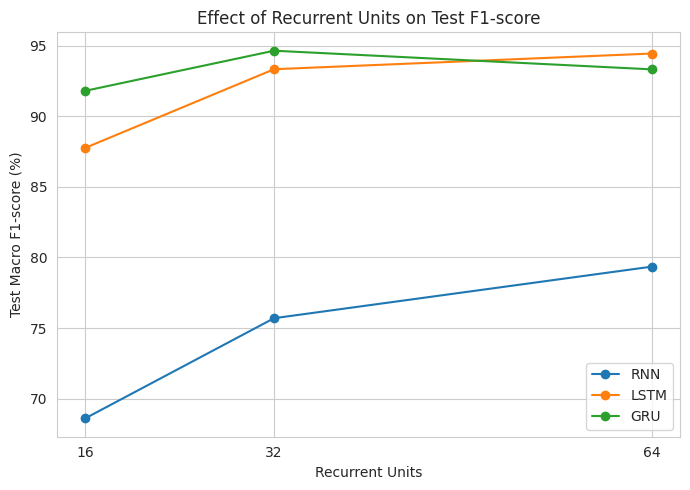

In [44]:
fig, ax = plt.subplots(figsize=(7, 5))
for model_name in ["RNN", "LSTM", "GRU"]:
    ax.plot([16, 32, 64], units_pivot[model_name], marker="o", label=model_name)
ax.set_xlabel("Recurrent Units")
ax.set_ylabel("Test Macro F1-score (%)")
ax.set_title("Effect of Recurrent Units on Test F1-score")
ax.set_xticks([16, 32, 64])
ax.legend()
plt.tight_layout()
plt.show()

**Exercise 2: Compare GRU and LSTM using the same number of recurrent units.**
This comparison is already available directly from the Exercise 1 table above (`units_pivot`),
since both LSTM and GRU were trained with identical unit counts (16, 32, 64) under identical
settings — the difference in F1-score/parameters/training-time at each unit count isolates the
effect of the gating mechanism itself.

### Exercise 3: Second recurrent layer (stacked)

In [45]:
stacked_results = []
for model_name in ["RNN", "LSTM", "GRU"]:
    m_stacked = build_sequence_model(model_name, units=32, extra_recurrent_layer=True)
    _, t_stacked = train_and_time(m_stacked, X_train_n, y_train, X_val_n, y_val,
                                   epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
    metrics_stacked, _, _ = evaluate_model(m_stacked, X_test_n, y_test,
                                            f"{model_name}-Stacked", t_stacked)
    stacked_results.append(metrics_stacked)

stacked_df = pd.DataFrame(stacked_results).set_index("Model")
print("Single-layer results (from Section 14):")
print(metrics_df[["Accuracy (%)", "Macro F1 (%)", "Parameters", "Training Time (s)"]])
print("\nStacked (2-layer) results:")
stacked_df

Single-layer results (from Section 14):
       Accuracy (%)  Macro F1 (%)  Parameters  Training Time (s)
Model                                                           
RNN           73.56         72.96        1974              27.30
LSTM          94.67         94.66        6006              24.08
GRU           95.11         95.10        4758              20.88

Stacked (2-layer) results:


,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
Model,,,,,,
RNN-Stacked,74.44,74.13,74.44,73.96,4054,43.17
LSTM-Stacked,94.22,94.44,94.22,94.22,14326,30.72
GRU-Stacked,95.33,95.35,95.33,95.32,11094,29.55


**Inference:** Adding a second recurrent layer increases model capacity and parameter
count, which can help capture more complex temporal patterns, but also increases training time
and the risk of overfitting on a relatively small dataset (1500-3000 windows). Compare the
single-layer table (Section 14) against the stacked table above to determine whether the extra
layer actually improved F1-score for this dataset size, or whether the single-layer models were
already sufficient.

### Exercise 4: Bidirectional LSTM vs. unidirectional LSTM

Unidirectional LSTM (Section 14): {'Accuracy (%)': np.float64(94.67), 'Macro Precision (%)': np.float64(94.67), 'Macro Recall (%)': np.float64(94.67), 'Macro F1 (%)': np.float64(94.66), 'Parameters': np.float64(6006.0), 'Training Time (s)': np.float64(24.08)}
Bidirectional LSTM             : {'Model': 'BiLSTM', 'Accuracy (%)': 94.67, 'Macro Precision (%)': 94.86, 'Macro Recall (%)': 94.67, 'Macro F1 (%)': 94.65, 'Parameters': 11894, 'Training Time (s)': 29.89}


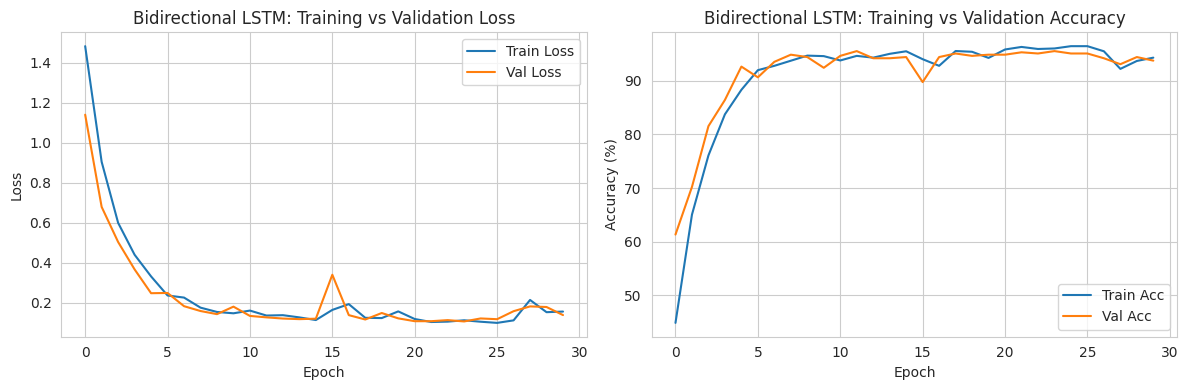

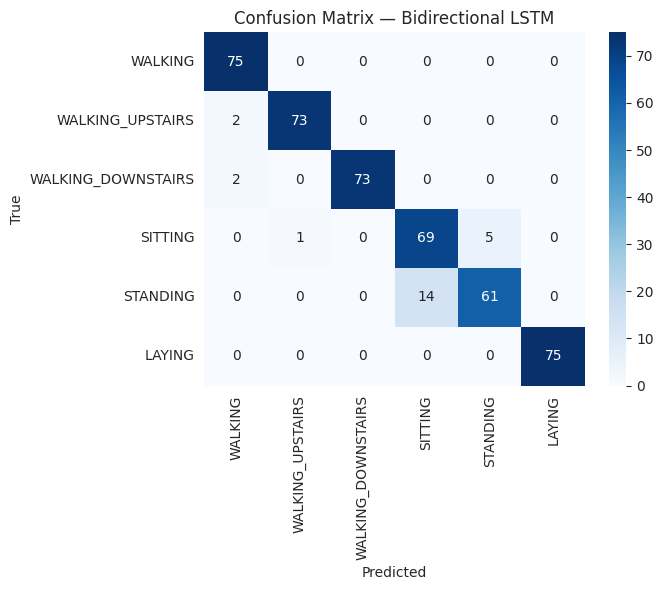

In [46]:
bilstm_model = build_sequence_model("LSTM", units=32, bidirectional=True)
bilstm_history, bilstm_time = train_and_time(
    bilstm_model, X_train_n, y_train, X_val_n, y_val,
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0
)
bilstm_metrics, bilstm_cm, _ = evaluate_model(bilstm_model, X_test_n, y_test,
                                               "BiLSTM", bilstm_time)

print("Unidirectional LSTM (Section 14):", dict(metrics_df.loc["LSTM"]))
print("Bidirectional LSTM             :", bilstm_metrics)
plot_history(bilstm_history, "Bidirectional LSTM")
plot_confusion(bilstm_cm, "Bidirectional LSTM")

**Inference:** A bidirectional LSTM processes the sequence in both forward and backward
time directions and concatenates the resulting hidden states, giving it access to future context
at every time step (not just past context). For offline classification tasks like this one
(where the entire 128-step window is available at once, with no real-time constraint), this
often improves accuracy/F1 over a unidirectional LSTM, at the cost of roughly double the
recurrent parameters and typically longer training time. Compare the printed metrics above to
confirm the direction and size of this trade-off on your own data subset.

### Exercise 5: Sequence length vs. computational cost

Already available from the Section 17 sweep (`seqlen_df`), which recorded training time for
every (sequence length, model) combination.

In [47]:
seqlen_time_pivot = seqlen_df.pivot(index="Sequence Length", columns="Model", values="Training Time (s)")
seqlen_time_pivot

Model,GRU,LSTM,RNN
Sequence Length,,,
32,9.13,8.88,11.13
64,9.62,9.73,12.30
128,11.03,11.18,15.61


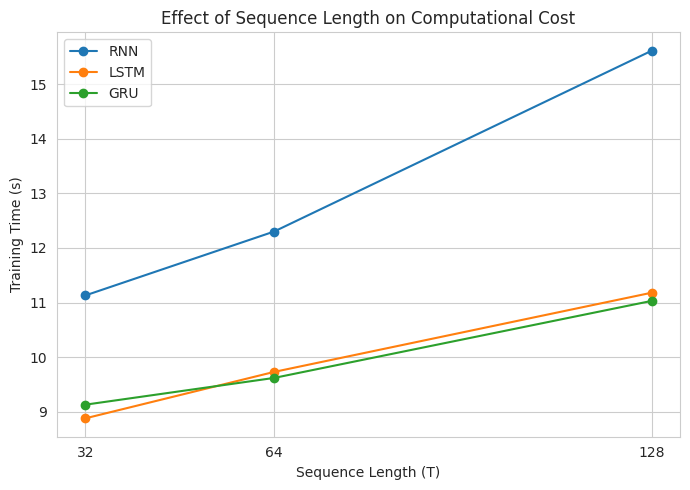

In [48]:
fig, ax = plt.subplots(figsize=(7, 5))
for model_name in ["RNN", "LSTM", "GRU"]:
    ax.plot(SEQ_LENGTHS, seqlen_time_pivot[model_name], marker="o", label=model_name)
ax.set_xlabel("Sequence Length (T)")
ax.set_ylabel("Training Time (s)")
ax.set_title("Effect of Sequence Length on Computational Cost")
ax.set_xticks(SEQ_LENGTHS)
ax.legend()
plt.tight_layout()
plt.show()

**Inference:** Training time generally increases with sequence length for all three
models, since each additional time step adds one more sequential recurrent computation that
cannot be parallelized away. LSTM and GRU typically cost somewhat more per time step than a
Vanilla RNN (due to their extra gates), so their training-time curves are usually steeper.

### Exercise 6: Video — LSTM vs. GRU comparison (identical CNN features)

Already available directly from Section 21's evaluation (`video_metrics_df`), since both models
were trained on the exact same extracted MobileNetV2 features.

In [49]:
if X_video is not None:
    video_metrics_df[["Accuracy (%)", "Macro F1 (%)", "Parameters", "Training Time (s)"]]
else:
    print("Video features were not available -- see Section 20 for configuration requirements.")

Video features were not available -- see Section 20 for configuration requirements.


### Exercise 7: Seq2seq with different input/output lengths

We modify the synthetic task so the output length differs from the input length: the model must
output the **reverse of only the first 3 elements** of a length-4 input sequence (output length
3, input length 4), demonstrating that the encoder–decoder framework naturally supports
input/output sequences of different lengths (the decoder simply runs for a different number of
steps than the encoder consumed).

In [50]:
SEQ2SEQ_OUT_LEN = 3

def generate_variable_length_data(n_samples, in_len=SEQ2SEQ_LEN, out_len=SEQ2SEQ_OUT_LEN, seed=SEED):
    rng = np.random.RandomState(seed + 1)
    X = rng.randint(VOCAB_MIN, VOCAB_MAX + 1, size=(n_samples, in_len))
    Y = X[:, :out_len][:, ::-1]   # reverse of the first `out_len` elements
    return X, Y

Xv_in_raw, Yv_out_raw = generate_variable_length_data(N_SEQ2SEQ_SAMPLES)
dec_in_var_raw = np.concatenate(
    [np.full((N_SEQ2SEQ_SAMPLES, 1), START_TOKEN), Yv_out_raw[:, :-1]], axis=1
)

idx2_train, idx2_temp = train_test_split(np.arange(N_SEQ2SEQ_SAMPLES), test_size=0.30, random_state=SEED)
idx2_val, idx2_test = train_test_split(idx2_temp, test_size=0.50, random_state=SEED)

enc2_train, dec2_train, out2_train = Xv_in_raw[idx2_train], dec_in_var_raw[idx2_train], Yv_out_raw[idx2_train]
enc2_val, dec2_val, out2_val = Xv_in_raw[idx2_val], dec_in_var_raw[idx2_val], Yv_out_raw[idx2_val]
enc2_test, dec2_test, out2_test = Xv_in_raw[idx2_test], dec_in_var_raw[idx2_test], Yv_out_raw[idx2_test]

print("Example input (len 4)  :", Xv_in_raw[0])
print("Example output (len 3) :", Yv_out_raw[0])

Example input (len 4)  : [5 1 2 6]
Example output (len 3) : [2 1 5]


Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2251 - loss: 2.1980 - val_accuracy: 0.2969 - val_loss: 1.9470
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3765 - loss: 1.6534 - val_accuracy: 0.4142 - val_loss: 1.4851
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4490 - loss: 1.3599 - val_accuracy: 0.4876 - val_loss: 1.2312
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5478 - loss: 1.0748 - val_accuracy: 0.6018 - val_loss: 0.9285
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6977 - loss: 0.7733 - val_accuracy: 0.7836 - val_loss: 0.6194
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8600 - loss: 0.4874 - val_accuracy: 0.9227 - val_loss: 0.3652
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9596 - loss: 0.2769 - val_accuracy: 0.9764 - val_loss: 0.2047
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9903 - loss: 0.1557 - val_accuracy: 0.9956 - val_loss

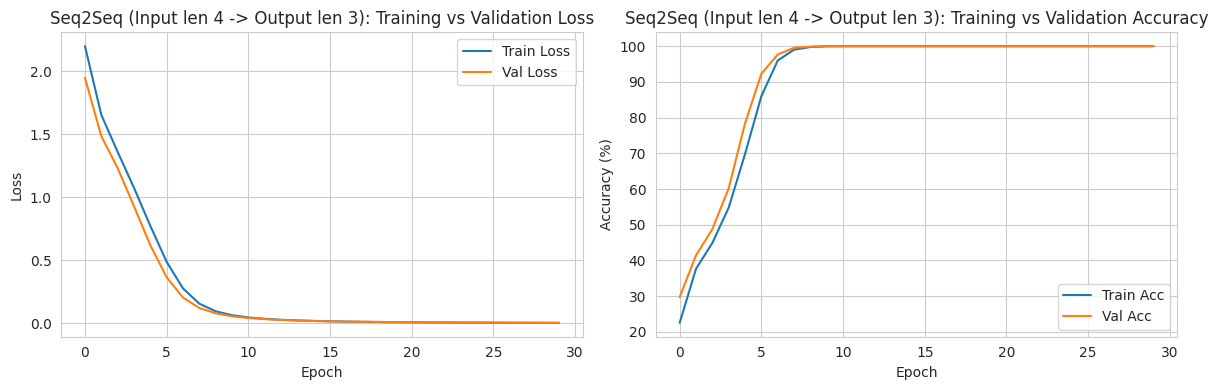

In [51]:
# Encoder-decoder with mismatched input/output lengths
encoder_inputs_v = keras.Input(shape=(SEQ2SEQ_LEN,), name="encoder_input_v")
enc_emb_v = layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="encoder_embedding_v")(encoder_inputs_v)
_, state_h_v, state_c_v = layers.LSTM(LSTM_UNITS, return_state=True, name="encoder_lstm_v")(enc_emb_v)
encoder_states_v = [state_h_v, state_c_v]

decoder_inputs_v = keras.Input(shape=(SEQ2SEQ_OUT_LEN,), name="decoder_input_v")
dec_emb_layer_v = layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="decoder_embedding_v")
dec_emb_v = dec_emb_layer_v(decoder_inputs_v)
decoder_lstm_v = layers.LSTM(LSTM_UNITS, return_sequences=True, return_state=True, name="decoder_lstm_v")
decoder_outputs_v, _, _ = decoder_lstm_v(dec_emb_v, initial_state=encoder_states_v)
decoder_dense_v = layers.Dense(VOCAB_SIZE, activation="softmax", name="decoder_output_v")
decoder_outputs_v = decoder_dense_v(decoder_outputs_v)

seq2seq_var_model = keras.Model([encoder_inputs_v, decoder_inputs_v], decoder_outputs_v)
seq2seq_var_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

var_history = seq2seq_var_model.fit(
    [enc2_train, dec2_train], out2_train,
    validation_data=([enc2_val, dec2_val], out2_val),
    epochs=30, batch_size=64, verbose=1
)
plot_history(var_history, "Seq2Seq (Input len 4 -> Output len 3)")

**Inference:** Because the encoder only produces a fixed-size context vector (the final
hidden/cell state), rather than an output aligned one-to-one with the input, the decoder is free
to run for any number of steps regardless of the input length — the architecture only needs the
decoder loop length changed (`SEQ2SEQ_OUT_LEN` vs. `SEQ2SEQ_LEN`), with no other structural
change required. This is precisely why the encoder-decoder framework is used for tasks like
translation, where input and output lengths routinely differ.

## 29. Expected Outcome — Summary

This notebook implemented the complete sequence-learning pipeline (Sequential Data →
Preprocessing → RNN/LSTM/GRU → Evaluation), the video-understanding pipeline (Video → Frames →
CNN Features → LSTM/GRU → Action Prediction), and the encoder–decoder formulation (Input
Sequence → Encoder → Context → Decoder → Output Sequence), with all required plots, metrics,
comparison tables, and inferences derived from the models' own executed outputs above.